# High-Dimensional Vocabulary Learning Experiment

## Overview

This notebook implements a high-dimensional vocabulary learning experiment to study how different architectures learn representations in a signal detection task.

## Experimental Setup

### Dataset
- **Vocabulary**: Random vocabulary {f₁, f₂, ..., f_c} where each f_i ∈ S^(m-1) (unit sphere in R^m)
- **Input**: D-dimensional vector divided into J patches of size m
  - One random patch contains a random vocabulary vector f_i + Gaussian noise
  - Other patches contain only Gaussian noise
  - Total noise energy = 1
- **Label**: The vocabulary vector f_i ∈ R^m (regression task)

### Models Compared
1. **CNN (Parameter Sharing)**: Shared filters across patches + Global Average Pooling → R^m
2. **Locally Connected (No Sharing)**: Patch-specific filters (no pooling) → R^m  
3. **Fully Connected**: Standard MLP → R^m

### Evaluation Metrics
- **L² Error**: ||prediction - label||₂ on train/test sets
- **Representation Learning**: Cluster analysis, PCA/LDA visualization

### Key Questions
- Does parameter sharing help learn robust vocabulary representations?
- Which patch clusters are most informative about labels?
- Do learned CNN features align with natural patch structure?


## 1. Setup and Configuration

In [4]:
import matplotlib.pyplot as plt
# =============================================================================
# GLOBAL PLOTTING CONFIG (ICML Conference Format)
# =============================================================================
PLOT_CONFIG = {
    'title_fontsize': 18,
    'label_fontsize': 18,
    'tick_fontsize': 14,
    'legend_fontsize': 14,
    'linewidth': 2.5,
    'markersize': 12,
    'single_fig_size': (6, 5),
    'double_fig_size': (12, 5),
    'grid_alpha': 0.3,
    'dpi': 300,
}

plt.rcParams.update({
    'font.size': PLOT_CONFIG['tick_fontsize'],
    'axes.titlesize': PLOT_CONFIG['title_fontsize'],
    'axes.labelsize': PLOT_CONFIG['label_fontsize'],
    'xtick.labelsize': PLOT_CONFIG['tick_fontsize'],
    'ytick.labelsize': PLOT_CONFIG['tick_fontsize'],
    'legend.fontsize': PLOT_CONFIG['legend_fontsize'],
    'figure.dpi': PLOT_CONFIG['dpi'],
    'lines.linewidth': PLOT_CONFIG['linewidth'],
    'lines.markersize': PLOT_CONFIG['markersize'],
})

# Pretty colors and markers
PRETTY_COLORS = {'FCN': '#E74C3C', 'LCN-WS': '#3498DB'}
MARKERS = {'FCN': 's', 'LCN-WS': 'o'}

# Colors for different d values
D_COLORS = ['#E74C3C', '#3498DB', '#2ECC71', '#9B59B6', '#F39C12', '#1ABC9C']
D_COLORS_DARK = ['#C0392B', '#2874A6', '#1E8449', '#6C3483', '#B9770E', '#E91E63']
D_MARKERS = ['o', 's', '^', 'D', 'v', 'p']
D_LINESTYLES = ['-', '--', '-.', ':', (0, (3, 1, 1, 1)), (0, (5, 2))]

ARCH_DISPLAY_NAMES = {'fully_connected': 'FCN', 'shared_cnn': 'LCN-WS'}

# =============================================================================
# GLOBAL TICK FORMATTER
# =============================================================================
def decimal_tick_formatter(x, pos):
    """Format tick labels as decimals."""
    if x == 0:
        return '0'
    elif abs(x) >= 1:
        return f'{x:.1f}'
    elif abs(x) >= 0.1:
        return f'{x:.2f}'
    elif abs(x) >= 0.01:
        return f'{x:.3f}'
    else:
        return f'{x:.4f}'

print("Config loaded.")

Config loaded.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture, BayesianGaussianMixture
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from typing import Tuple, Dict
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device configuration - Support MPS for Apple Silicon
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f"Using device: {device}")
if device.type == 'mps':
    print("✓ Apple Silicon GPU (MPS) detected - Training will be much faster!")

Using device: mps
✓ Apple Silicon GPU (MPS) detected - Training will be much faster!


## Experiment Configuration

In [ ]:
# Data parameters
DATA_CONFIG = {
    'D': 500,              # Total dimension
    'm': 10,               # Patch size (vocabulary vector dimension)
    'J': 50,               # Number of patches (D/m)
    'c': 2,                # Vocabulary size
    'n_train': 200,        # Training samples
    'n_test': 5000,        # Test samples
}

# Model parameters
MODEL_CONFIG = {
    'cnn': {
        'K': 500,          # Number of shared filters
        'lr': 0.4,         # Learning rate
    },
    'lc': {
        'K': 10,            # Number of filters per patch
        'lr': 0.4,         # Learning rate
    },
    'fc': {
        'K': 20,           # Hidden dimension
        'lr': 0.4,         # Learning rate
    }
}

# Training parameters
TRAIN_CONFIG = {
    'epochs': 10000,        # Number of training epochs
    'batch_size': None,    # None = full batch training
    'weight_decay': 0.0,   # No weight decay
    'momentum': 0.0,       # No momentum
    'grad_clip': 100,       # Gradient clipping threshold
}

print("Experiment Configuration:")
print(f"Vocabulary size: {DATA_CONFIG['c']}")
print(f"Each vocabulary vector: {DATA_CONFIG['m']}-dimensional")
print(f"Total dimension: {DATA_CONFIG['D']}")
print(f"Number of patches: {DATA_CONFIG['J']}")
print(f"Training samples: {DATA_CONFIG['n_train']}")
print(f"Test samples: {DATA_CONFIG['n_test']}")

Experiment Configuration:
Vocabulary size: 2
Each vocabulary vector: 10-dimensional
Total dimension: 500
Number of patches: 50
Training samples: 200
Test samples: 5000


## 1. Data Generation

### Key Design Decisions

1. **Vocabulary Vectors**: Each f_i is sampled uniformly from unit sphere S^(m-1)
2. **Energy Balance**: Total Gaussian noise energy = 1 across all patches
3. **Random Patch Selection**: Signal location is randomized to prevent spatial bias

In [ ]:
def generate_patch_partition(D: int, m: int) -> np.ndarray:
    """
    Generate a random partition of indices into patches.
    
    Args:
        D: Total dimension
        m: Patch size
    
    Returns:
        H: Array of shape (J, m) where J = D/m
    """
    assert D % m == 0, "D must be divisible by m"
    J = D // m
    indices = np.random.permutation(D)
    H = indices.reshape(J, m)
    return H


def generate_vocabulary(c: int, m: int) -> np.ndarray:
    """
    Generate random vocabulary of unit vectors on sphere S^(m-1).
    
    Args:
        c: Vocabulary size
        m: Dimension of each vocabulary vector
    
    Returns:
        vocab: Array of shape (c, m) where each row is a unit vector
    """
    vocab = np.random.randn(c, m)
    vocab = vocab / np.linalg.norm(vocab, axis=1, keepdims=True)
    return vocab


def generate_dataset(n_samples: int, D: int, m: int, J: int, 
                    H: np.ndarray, vocabulary: np.ndarray) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Generate high-dimensional dataset with vocabulary vectors as labels.
    
    Args:
        n_samples: Number of samples
        D: Total dimension
        m: Patch size
        J: Number of patches
        H: Patch partition (J, m)
        vocabulary: Vocabulary vectors (c, m)
    
    Returns:
        X: Input data (n_samples, D)
        y: Labels (n_samples, m) - vocabulary vectors
    """
    c = vocabulary.shape[0]
    sigma = np.sqrt(1.0 / (J * m))  # Total noise energy = 1
    
    X = np.zeros((n_samples, D))
    y = np.zeros((n_samples, m))
    
    for i in range(n_samples):
        # Randomly choose vocabulary vector
        vocab_idx = np.random.randint(0, c)
        y[i] = vocabulary[vocab_idx]
        
        # Randomly choose signal patch location
        signal_patch_idx = np.random.randint(0, J)
        
        # Fill all patches with Gaussian noise
        for j in range(J):
            X[i, H[j]] = np.random.randn(m) * sigma
        
        # Place vocabulary vector + noise in signal patch
        X[i, H[signal_patch_idx]] = vocabulary[vocab_idx] + np.random.randn(m) * sigma
    
    return torch.FloatTensor(X), torch.FloatTensor(y)


# Generate patch partition
H = generate_patch_partition(DATA_CONFIG['D'], DATA_CONFIG['m'])
print(f"Patch partition: {H.shape}")
print(f"First patch indices: {H[0]}")

# Generate vocabulary
vocab = generate_vocabulary(DATA_CONFIG['c'], DATA_CONFIG['m'])
print(f"\nVocabulary: {vocab.shape}")
for i in range(DATA_CONFIG['c']):
    print(f"  f_{i+1}: norm = {np.linalg.norm(vocab[i]):.6f}")

# Generate datasets
X_train, y_train = generate_dataset(
    DATA_CONFIG['n_train'], DATA_CONFIG['D'], DATA_CONFIG['m'], 
    DATA_CONFIG['J'], H, vocab
)
X_test, y_test = generate_dataset(
    DATA_CONFIG['n_test'], DATA_CONFIG['D'], DATA_CONFIG['m'], 
    DATA_CONFIG['J'], H, vocab
)

print(f"\nTraining data: {X_train.shape}, Labels: {y_train.shape}")
print(f"Test data: {X_test.shape}, Labels: {y_test.shape}")

Patch partition: (50, 10)
First patch indices: [ 61 136 155   4 370 326 308 133 282 401]

Vocabulary: (2, 10)
  f_1: norm = 1.000000
  f_2: norm = 1.000000

Training data: torch.Size([200, 500]), Labels: torch.Size([200, 10])
Test data: torch.Size([5000, 500]), Labels: torch.Size([5000, 10])


## 2. Model Architectures

Three architectures with vector output R^m:

### CNN (Parameter Sharing)
- Shared filters across all patches
- Global Average Pooling aggregates patch-level features
- Linear readout: R^K → R^m

### Locally Connected (No Sharing)
- Each patch has dedicated filters
- No pooling - preserves spatial information
- Linear readout: R^(J×K) → R^m

### Fully Connected
- Standard MLP: R^D → R^K → R^m
- No structural bias

In [10]:
# Helper functions for data reshaping
def reorder_data(X, H):
    """Reorder data according to patch partition H."""
    H_flat = H.flatten()
    return X[:, H_flat].contiguous()


def reshape_to_patches(X, J, m):
    """Reshape reordered data into patch format (n_samples, J, m)."""
    return X.view(X.shape[0], J, m).contiguous()


# Model Definitions
class CNNModelHighDim(nn.Module):
    """CNN model with high-dimensional output (R^K -> R^m after GAP)."""
    
    def __init__(self, d: int, K: int, m_out: int, H: np.ndarray):
        """
        Args:
            d: Total input dimension
            K: Number of shared filters
            m_out: Output dimension (vocabulary vector dimension)
            H: Patch partition array (J, m)
        """
        super(CNNModelHighDim, self).__init__()
        self.d = d
        self.K = K
        self.m_out = m_out
        self.J = H.shape[0]  # Number of patches
        self.m = H.shape[1]  # Patch size
        
        # Shared filters (K filters of size m)
        self.w = nn.Parameter(torch.randn(K, self.m))
        self.b = nn.Parameter(torch.zeros(K))
        
        # Output layer: R^K -> R^m_out (matrix V and bias beta)
        self.V = nn.Parameter(torch.randn(K, m_out))
        self.beta = nn.Parameter(torch.zeros(m_out))
        
        # Initialize
        std = np.sqrt(2.0 / self.m)
        nn.init.normal_(self.w, mean=0, std=std)
        nn.init.normal_(self.V, std=1/np.sqrt(K))
    
    def forward(self, x):
        """
        Forward pass - Expects x in shape (batch, J, m).
        
        Args:
            x: Input (batch_size, J, m) - Pre-reshaped patches
        
        Returns:
            output: Predictions (batch_size, m_out)
        """
        # Single batch matmul: (batch, J, m) @ (m, K) -> (batch, J, K)
        hidden = torch.matmul(x, self.w.t())  # (batch, J, K)
        hidden = hidden - self.b  # Broadcast bias
        hidden = torch.relu(hidden)
        
        # Global average pooling: (batch, J, K) -> (batch, K)
        pooled = hidden.mean(dim=1)
        
        # Output: (batch, K) @ (K, m_out) -> (batch, m_out)
        return torch.matmul(pooled, self.V) + self.beta


class LocallyConnectedModelHighDim(nn.Module):
    """Locally connected model with high-dimensional output."""
    
    def __init__(self, d: int, K: int, m_out: int, H: np.ndarray):
        """
        Args:
            d: Total input dimension
            K: Number of filters per patch
            m_out: Output dimension
            H: Patch partition array (J, m)
        """
        super(LocallyConnectedModelHighDim, self).__init__()
        self.d = d
        self.K = K
        self.m_out = m_out
        self.J = H.shape[0]  # Number of patches
        self.m = H.shape[1]  # Patch size
        
        # Separate weights for each patch: (J, K, m)
        self.w = nn.Parameter(torch.empty(self.J, K, self.m))
        self.b = nn.Parameter(torch.zeros(self.J, K))
        
        # Output layer weights: R^(J*K) -> R^m_out
        self.V = nn.Parameter(torch.empty(self.J * K, m_out))
        self.beta = nn.Parameter(torch.zeros(m_out))
        
        # Initialize weights
        std = np.sqrt(2.0 / self.m)
        nn.init.normal_(self.w, mean=0, std=std)
        nn.init.normal_(self.V, std=1/np.sqrt(self.J * K))
    
    def forward(self, x):
        """
        Forward pass.
        
        Args:
            x: Input (batch_size, d)
        
        Returns:
            output: Predictions (batch_size, m_out)
        """
        batch_size = x.shape[0]
        
        # Reshape to patches (data is pre-reordered)
        x_patches = x.view(batch_size, self.J, self.m)  # (batch, J, m)
        
        # Apply patch-specific filters
        hidden = torch.einsum('bjm,jkm->bjk', x_patches, self.w) - self.b
        hidden = torch.relu(hidden)
        
        # Flatten hidden activations: (batch_size, J*K)
        hidden_flat = hidden.reshape(batch_size, -1)
        
        # Output layer: (batch_size, J*K) @ (J*K, m_out) -> (batch_size, m_out)
        output = torch.matmul(hidden_flat, self.V) + self.beta
        
        return output


class FCModelHighDim(nn.Module):
    """Fully connected model with high-dimensional output."""
    
    def __init__(self, d: int, K: int, m_out: int):
        """
        Args:
            d: Input dimension
            K: Hidden layer dimension
            m_out: Output dimension
        """
        super(FCModelHighDim, self).__init__()
        self.d = d
        self.K = K
        self.m_out = m_out
        
        # Two-layer MLP: R^d -> R^K -> R^m_out
        self.fc1 = nn.Linear(d, K)
        self.fc2 = nn.Linear(K, m_out)
        
        # Initialize weights
        nn.init.kaiming_normal_(self.fc1.weight, mode='fan_in', nonlinearity='relu')
        nn.init.normal_(self.fc2.weight, std=1/np.sqrt(K))
    
    def forward(self, x):
        """
        Forward pass.
        
        Args:
            x: Input (batch_size, d)
        
        Returns:
            output: Predictions (batch_size, m_out)
        """
        hidden = torch.relu(self.fc1(x))
        output = self.fc2(hidden)
        return output


# Instantiate models
model_cnn = CNNModelHighDim(
    d=DATA_CONFIG['D'],
    K=MODEL_CONFIG['cnn']['K'],
    m_out=DATA_CONFIG['m'],
    H=H
).to(device)

model_lc = LocallyConnectedModelHighDim(
    d=DATA_CONFIG['D'],
    K=MODEL_CONFIG['lc']['K'],
    m_out=DATA_CONFIG['m'],
    H=H
).to(device)

model_fc = FCModelHighDim(
    d=DATA_CONFIG['D'],
    K=MODEL_CONFIG['fc']['K'],
    m_out=DATA_CONFIG['m']
).to(device)

print("Models initialized:")
print(f"CNN parameters: {sum(p.numel() for p in model_cnn.parameters()):,}")
print(f"LC parameters: {sum(p.numel() for p in model_lc.parameters()):,}")
print(f"FC parameters: {sum(p.numel() for p in model_fc.parameters()):,}")


Models initialized:
CNN parameters: 10,510
LC parameters: 10,510
FC parameters: 10,230


## 3. Training

Train all three models with MSE loss and track L² error metrics.


In [11]:
def train_model_highdim(model, X_train, y_train, X_test, y_test, 
                        lr, epochs, grad_clip=None, model_name="Model"):
    """
    Train a high-dimensional model and track L^2 error metrics.
    
    Args:
        model: PyTorch model
        X_train, y_train: Training data (y_train is multi-dimensional)
        X_test, y_test: Test data
        lr: Learning rate
        epochs: Number of epochs
        grad_clip: Gradient clipping threshold
        model_name: Name for logging
    
    Returns:
        history: Dictionary with training metrics
    """
    # Move data to device
    X_train = X_train.to(device)
    y_train = y_train.to(device)
    X_test = X_test.to(device)
    y_test = y_test.to(device)
    
    # Setup optimizer and loss
    optimizer = optim.SGD(
        model.parameters(), 
        lr=lr, 
        momentum=TRAIN_CONFIG['momentum'],
        weight_decay=TRAIN_CONFIG['weight_decay']
    )
    criterion = nn.MSELoss()
    
    # History tracking
    history = {
        'train_loss': [],
        'test_loss': [],
        'train_l2_error': [],  # Average L^2 error per sample
        'test_l2_error': []
    }
    
    print(f"\nTraining {model_name} (High-Dimensional)...")
    print(f"Learning rate: {lr}")
    print(f"Gradient clipping: {grad_clip if grad_clip else 'None'}")
    print("-" * 60)
    
    for epoch in range(epochs):
        # Training
        model.train()
        optimizer.zero_grad()
        
        # Forward pass (full batch)
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        
        # Backward pass
        loss.backward()
        
        # Gradient clipping (if enabled)
        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        
        optimizer.step()
        
        # Evaluation
        with torch.no_grad():
            # Training metrics (reuse outputs from training forward pass)
            train_loss = loss.item()
            train_l2_error = torch.norm(outputs - y_train, dim=1).mean().item()
            
            # Test metrics
            model.eval()
            test_outputs = model(X_test)
            test_loss = criterion(test_outputs, y_test).item()
            test_l2_error = torch.norm(test_outputs - y_test, dim=1).mean().item()
        
        # Record history
        history['train_loss'].append(train_loss)
        history['test_loss'].append(test_loss)
        history['train_l2_error'].append(train_l2_error)
        history['test_l2_error'].append(test_l2_error)
        
        # Print progress
        if (epoch + 1) % 100 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:4d} | "
                  f"Train Loss: {train_loss:.4f} | "
                  f"Test Loss: {test_loss:.4f} | "
                  f"Train L2: {train_l2_error:.4f} | "
                  f"Test L2: {test_l2_error:.4f}")
    
    print(f"\nFinal {model_name} Test L^2 Error: {history['test_l2_error'][-1]:.4f}")
    return history


# Prepare data for high-dimensional models
print("\nPreparing data for high-dimensional patch-based models...")
X_train_reordered = reorder_data(X_train, H)
X_test_reordered = reorder_data(X_test, H)
print("✓ Data reordered (patches now contiguous)")

# Pre-reshape for CNN: (B, d) -> (B, J, m)
X_train_cnn = reshape_to_patches(X_train_reordered, DATA_CONFIG['J'], DATA_CONFIG['m'])
X_test_cnn = reshape_to_patches(X_test_reordered, DATA_CONFIG['J'], DATA_CONFIG['m'])
print(f"✓ CNN data reshaped: {X_train_cnn.shape}")

# LC uses flat format: (B, d)
print(f"✓ LC data format: {X_train_reordered.shape}")

# Train all three high-dimensional models
history_cnn = train_model_highdim(
    model_cnn, X_train_cnn, y_train, X_test_cnn, y_test,
    lr=MODEL_CONFIG['cnn']['lr'],
    epochs=TRAIN_CONFIG['epochs'],
    grad_clip=TRAIN_CONFIG['grad_clip'],
    model_name="CNN"
)

history_lc = train_model_highdim(
    model_lc, X_train_reordered, y_train, X_test_reordered, y_test,
    lr=MODEL_CONFIG['lc']['lr'],
    epochs=TRAIN_CONFIG['epochs'],
    grad_clip=TRAIN_CONFIG['grad_clip'],
    model_name="Locally Connected"
)

history_fc = train_model_highdim(
    model_fc, X_train, y_train, X_test, y_test,
    lr=MODEL_CONFIG['fc']['lr'],
    epochs=TRAIN_CONFIG['epochs'],
    grad_clip=TRAIN_CONFIG['grad_clip'],
    model_name="Fully Connected"
)



Preparing data for high-dimensional patch-based models...
✓ Data reordered (patches now contiguous)
✓ CNN data reshaped: torch.Size([200, 50, 10])
✓ LC data format: torch.Size([200, 500])

Training CNN (High-Dimensional)...
Learning rate: 0.4
Gradient clipping: 100
------------------------------------------------------------
Epoch    1 | Train Loss: 0.1052 | Test Loss: 0.0861 | Train L2: 1.0257 | Test L2: 0.9279
Epoch  100 | Train Loss: 0.0250 | Test Loss: 0.0255 | Train L2: 0.4984 | Test L2: 0.5031
Epoch  200 | Train Loss: 0.0235 | Test Loss: 0.0239 | Train L2: 0.4824 | Test L2: 0.4871
Epoch  300 | Train Loss: 0.0220 | Test Loss: 0.0224 | Train L2: 0.4668 | Test L2: 0.4715
Epoch  400 | Train Loss: 0.0206 | Test Loss: 0.0210 | Train L2: 0.4514 | Test L2: 0.4561
Epoch  500 | Train Loss: 0.0193 | Test Loss: 0.0197 | Train L2: 0.4362 | Test L2: 0.4411
Epoch  600 | Train Loss: 0.0181 | Test Loss: 0.0185 | Train L2: 0.4213 | Test L2: 0.4262
Epoch  700 | Train Loss: 0.0169 | Test Loss: 0.01

## 4. Visualization

Plot training curves for all three models.


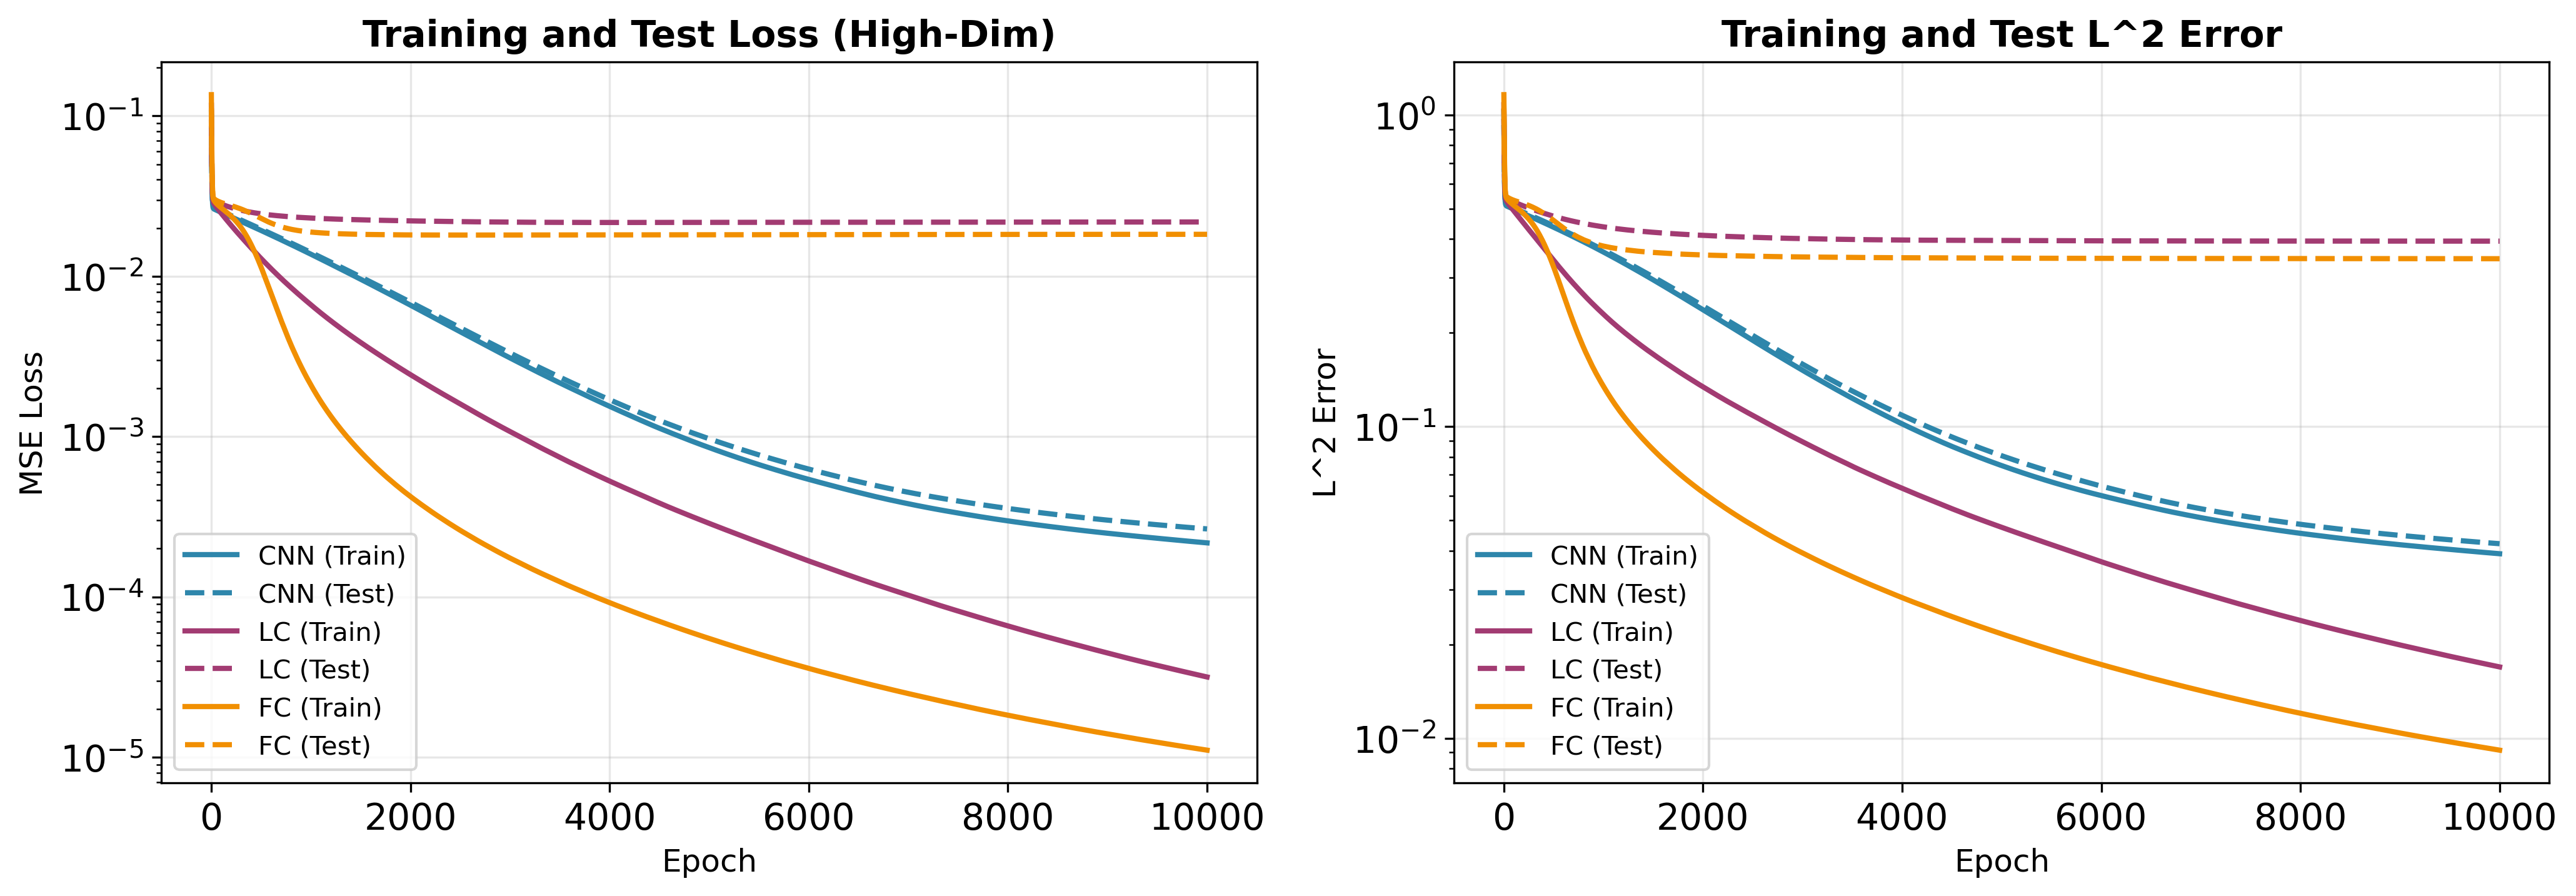

In [12]:
def plot_highdim_training_curves(histories, model_names):
    """
    Plot training curves for high-dimensional models.
    
    Args:
        histories: List of history dictionaries
        model_names: List of model names
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    colors = ['#2E86AB', '#A23B72', '#F18F01']
    
    # Loss curves
    ax = axes[0]
    for i, (history, name) in enumerate(zip(histories, model_names)):
        epochs = range(1, len(history['train_loss']) + 1)
        ax.plot(epochs, history['train_loss'], 
                label=f'{name} (Train)', color=colors[i], linestyle='-', linewidth=2)
        ax.plot(epochs, history['test_loss'], 
                label=f'{name} (Test)', color=colors[i], linestyle='--', linewidth=2)
    
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('MSE Loss', fontsize=12)
    ax.set_title('Training and Test Loss (High-Dim)', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')
    
    # L^2 Error curves
    ax = axes[1]
    for i, (history, name) in enumerate(zip(histories, model_names)):
        epochs = range(1, len(history['train_l2_error']) + 1)
        ax.plot(epochs, history['train_l2_error'], 
                label=f'{name} (Train)', color=colors[i], linestyle='-', linewidth=2)
        ax.plot(epochs, history['test_l2_error'], 
                label=f'{name} (Test)', color=colors[i], linestyle='--', linewidth=2)
    
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('L^2 Error', fontsize=12)
    ax.set_title('Training and Test L^2 Error', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')
    
    plt.tight_layout()
    plt.show()


# Plot all high-dimensional models
plot_highdim_training_curves(
    [history_cnn, history_lc, history_fc],
    ['CNN', 'LC', 'FC']
)


Figure saved to training_loss_and_generalization_gap.pdf


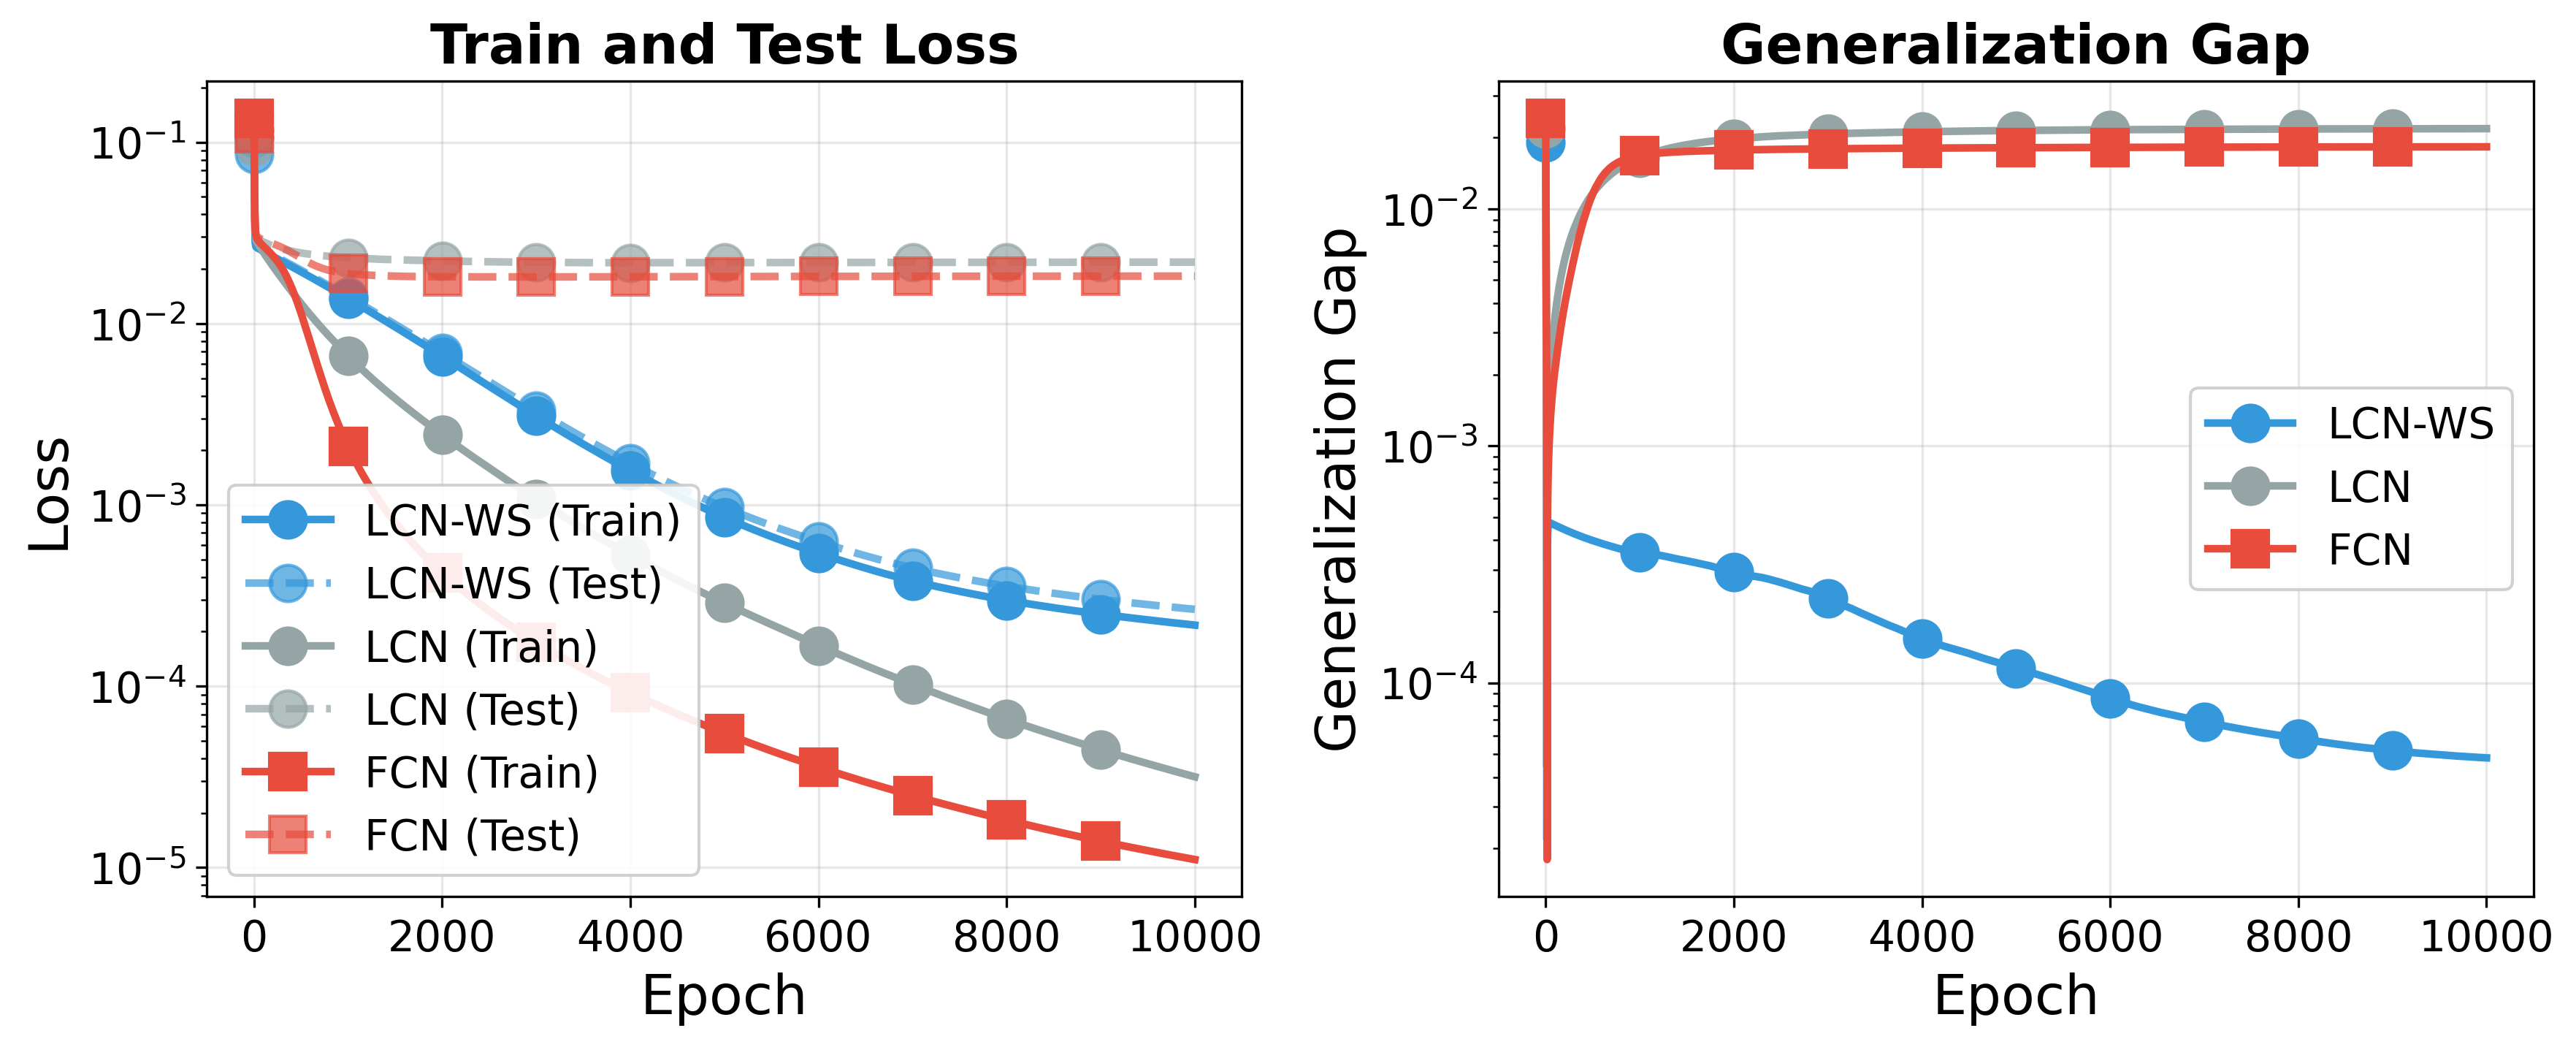

In [21]:
# =============================================================================
# Visualization: Training Loss and Generalization Gap (ICML Format)
# =============================================================================

def plot_all_models_loss(histories, model_names, save_path=None):
    """
    Plot training/test loss and generalization gap for all models with ICML conference format.
    
    Args:
        histories: List of history dictionaries
        model_names: List of model names (e.g., ['LCN-WS', 'LC', 'FCN'])
        save_path: Optional path to save the figure as PDF (e.g., 'figure.pdf')
    """
    from matplotlib.ticker import LogFormatterMathtext
    
    # Define colors for three models
    model_colors = {
        'LCN-WS': '#3498DB',  # Blue
        'LC': '#2ECC71',      # Green
        'FCN': '#E74C3C'      # Red
    }
    
    model_markers = {
        'LCN-WS': 'o',
        'LC': '^',
        'FCN': 's'
    }
    
    # Create 1x2 subplot layout (horizontal)
    fig, axes = plt.subplots(1, 2, figsize=PLOT_CONFIG['double_fig_size'])
    
    # =========================================================================
    # Top subplot: Train and Test Loss
    # =========================================================================
    ax1 = axes[0]
    
    for history, model_name in zip(histories, model_names):
        epochs = range(1, len(history['train_loss']) + 1)
        color = model_colors.get(model_name, '#95a5a6')
        marker = model_markers.get(model_name, 'o')
        
        # Plot training loss (solid line)
        ax1.plot(epochs, history['train_loss'], 
                label=f'{model_name} (Train)', 
                color=color, 
                linestyle='-', 
                linewidth=PLOT_CONFIG['linewidth'],
                marker=marker,
                markevery=len(epochs)//10,
                markersize=PLOT_CONFIG['markersize'])
        
        # Plot test loss (dashed line)
        ax1.plot(epochs, history['test_loss'], 
                label=f'{model_name} (Test)', 
                color=color, 
                linestyle='--', 
                linewidth=PLOT_CONFIG['linewidth'],
                marker=marker,
                markevery=len(epochs)//10,
                markersize=PLOT_CONFIG['markersize'],
                alpha=0.7)
    
    ax1.set_xlabel('Epoch', fontsize=PLOT_CONFIG['label_fontsize'])
    ax1.set_ylabel('Loss', fontsize=PLOT_CONFIG['label_fontsize'])
    ax1.set_title('Train and Test Loss', fontsize=PLOT_CONFIG['title_fontsize'], fontweight='bold')
    ax1.legend(fontsize=PLOT_CONFIG['legend_fontsize'], framealpha=0.9, loc='best')
    ax1.grid(True, alpha=PLOT_CONFIG['grid_alpha'])
    ax1.set_yscale('log')
    
    # Use power-of-10 notation for y-axis (10^{-1}, 10^{-2}, etc.)
    ax1.yaxis.set_major_formatter(LogFormatterMathtext())
    
    # =========================================================================
    # Bottom subplot: Generalization Gap
    # =========================================================================
    ax2 = axes[1]
    
    for history, model_name in zip(histories, model_names):
        epochs = range(1, len(history['train_loss']) + 1)
        color = model_colors.get(model_name, '#95a5a6')
        marker = model_markers.get(model_name, 'o')
        
        # Calculate generalization gap: |test_loss - train_loss|
        train_loss = np.array(history['train_loss'])
        test_loss = np.array(history['test_loss'])
        gen_gap = np.abs(test_loss - train_loss)
        
        # Plot generalization gap
        ax2.plot(epochs, gen_gap, 
                label=f'{model_name}', 
                color=color, 
                linestyle='-', 
                linewidth=PLOT_CONFIG['linewidth'],
                marker=marker,
                markevery=len(epochs)//10,
                markersize=PLOT_CONFIG['markersize'])
    
    ax2.set_xlabel('Epoch', fontsize=PLOT_CONFIG['label_fontsize'])
    ax2.set_ylabel('Generalization Gap', fontsize=PLOT_CONFIG['label_fontsize'])
    ax2.set_title('Generalization Gap', fontsize=PLOT_CONFIG['title_fontsize'], fontweight='bold')
    ax2.legend(fontsize=PLOT_CONFIG['legend_fontsize'], framealpha=0.9, loc='best')
    ax2.grid(True, alpha=PLOT_CONFIG['grid_alpha'])
    ax2.set_yscale('log')
    
    # Use power-of-10 notation for y-axis (10^{-1}, 10^{-2}, etc.)
    ax2.yaxis.set_major_formatter(LogFormatterMathtext())
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, format='pdf', dpi=PLOT_CONFIG['dpi'], bbox_inches='tight')
        print(f"Figure saved to {save_path}")
    
    plt.show()


# Plot all three models together (CNN -> LCN-WS)
plot_all_models_loss(
    [history_cnn, history_lc, history_fc],
    ['LCN-WS', 'LCN', 'FCN'],
    save_path='training_loss_and_generalization_gap.pdf'
)

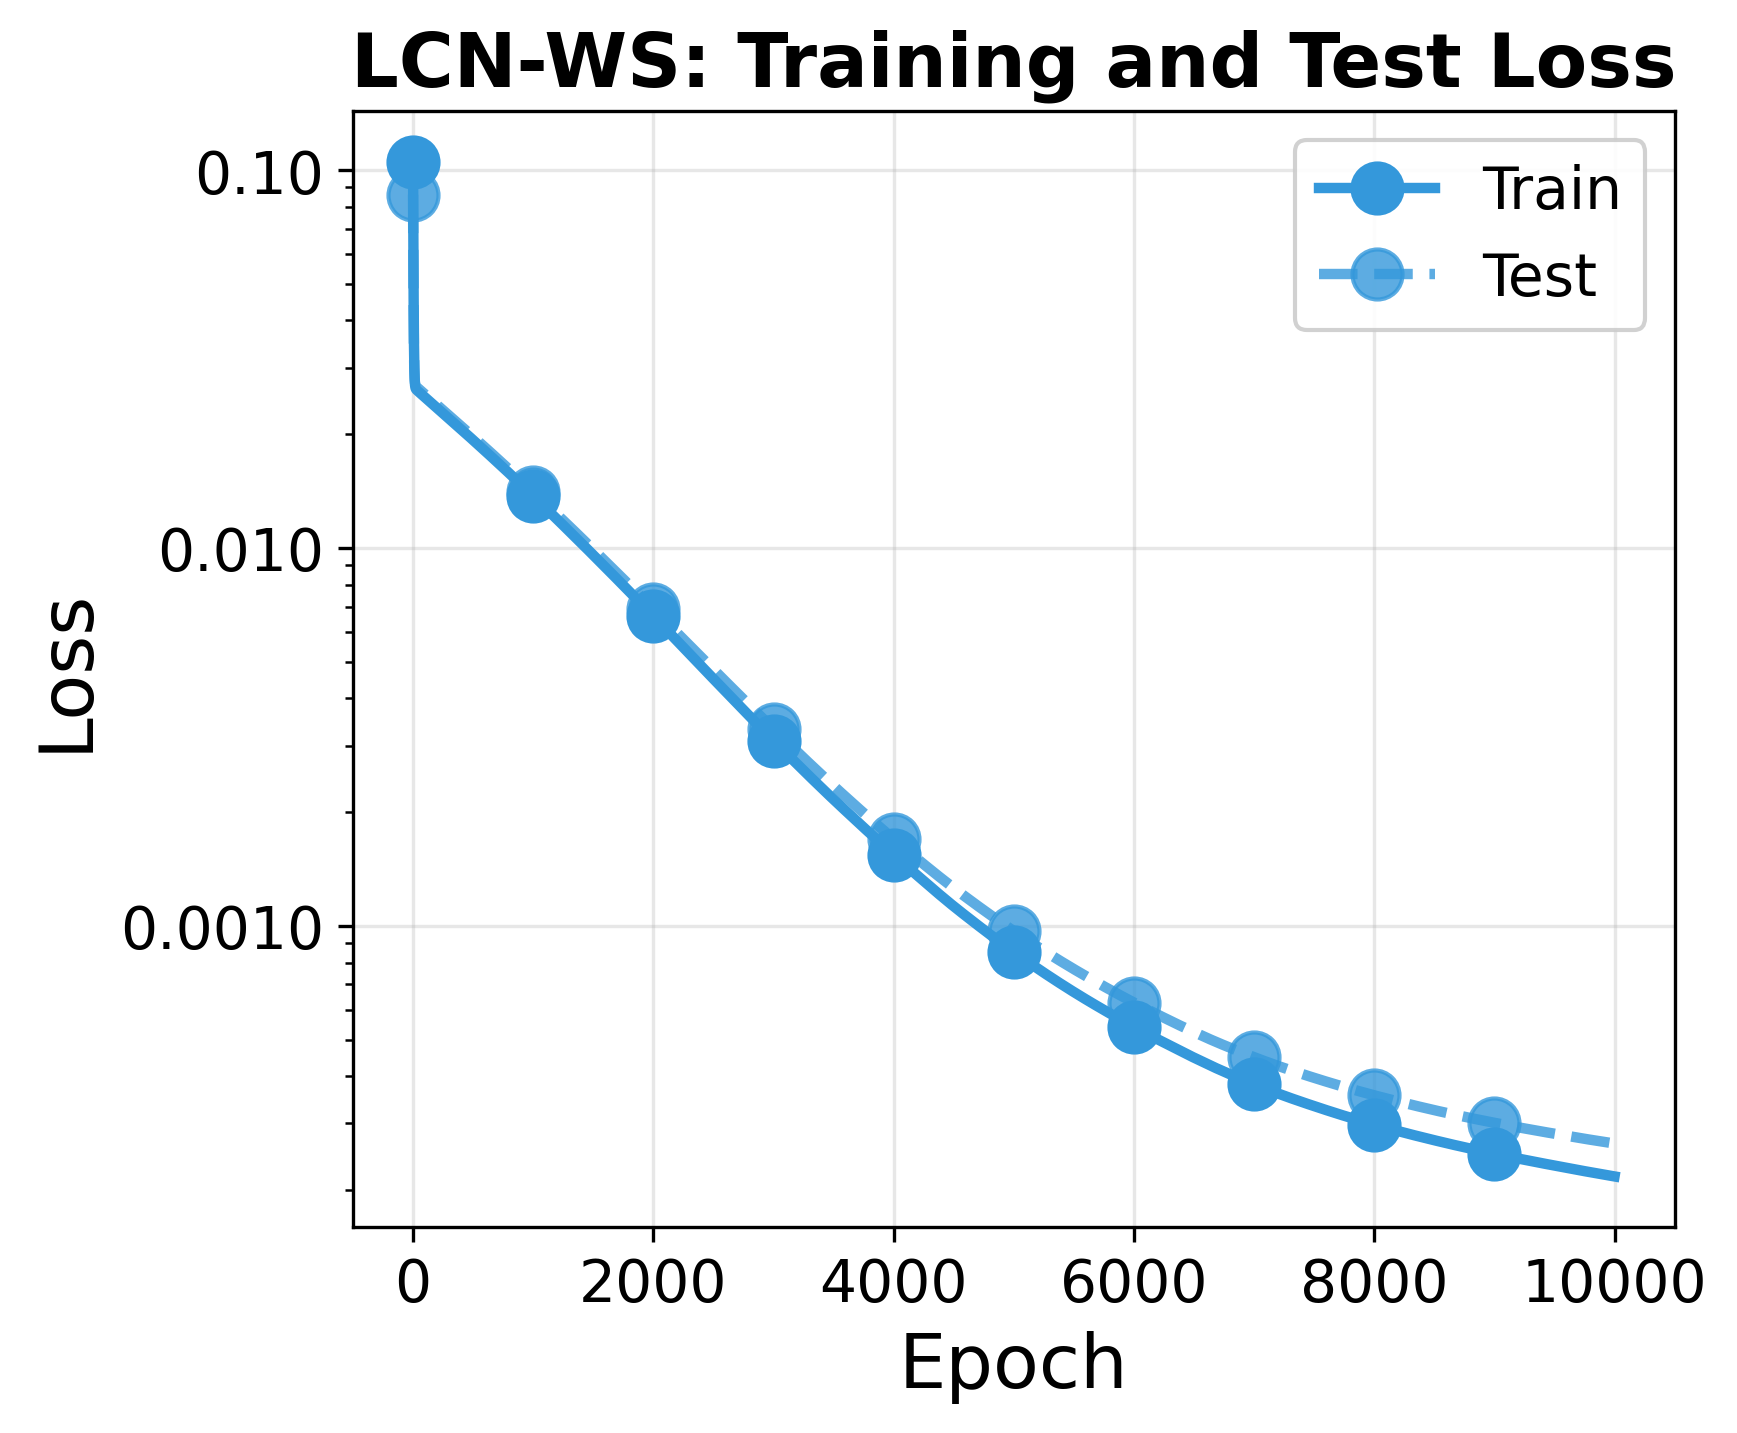

In [18]:
# =============================================================================
# Visualization: Training and Test Loss for LCN-WS
# =============================================================================

def plot_lcnws_loss(history, save_path=None):
    """
    Plot training and test loss for LCN-WS model.
    
    Args:
        history: Dictionary containing 'train_loss' and 'test_loss'
        save_path: Optional path to save the figure
    """
    from matplotlib.ticker import FuncFormatter
    
    fig, ax = plt.subplots(1, 1, figsize=PLOT_CONFIG['single_fig_size'])
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Plot training loss
    ax.plot(epochs, history['train_loss'], 
            label='Train', 
            color=PRETTY_COLORS['LCN-WS'], 
            linestyle='-', 
            linewidth=PLOT_CONFIG['linewidth'],
            marker=MARKERS['LCN-WS'],
            markevery=len(epochs)//10,
            markersize=PLOT_CONFIG['markersize'])
    
    # Plot test loss
    ax.plot(epochs, history['test_loss'], 
            label='Test', 
            color=PRETTY_COLORS['LCN-WS'], 
            linestyle='--', 
            linewidth=PLOT_CONFIG['linewidth'],
            marker=MARKERS['LCN-WS'],
            markevery=len(epochs)//10,
            markersize=PLOT_CONFIG['markersize'],
            alpha=0.8)
    
    ax.set_xlabel('Epoch', fontsize=PLOT_CONFIG['label_fontsize'])
    ax.set_ylabel('Loss', fontsize=PLOT_CONFIG['label_fontsize'])
    ax.set_title('LCN-WS: Training and Test Loss', fontsize=PLOT_CONFIG['title_fontsize'], fontweight='bold')
    ax.legend(fontsize=PLOT_CONFIG['legend_fontsize'], framealpha=0.9)
    ax.grid(True, alpha=PLOT_CONFIG['grid_alpha'])
    ax.set_yscale('log')
    
    # Apply decimal formatter to y-axis
    ax.yaxis.set_major_formatter(FuncFormatter(decimal_tick_formatter))
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=PLOT_CONFIG['dpi'], bbox_inches='tight')
        print(f"Figure saved to {save_path}")
    
    plt.show()


# Plot the LCN-WS training and test loss
plot_lcnws_loss(history_cnn)